# Import

In [1]:
!pip install catboost -q
!pip install lightgbm -q
!pip install seaborn -q
!pip install scikit-learn -q
!pip install xgboost -q
!pip install umap-learn -q 
!pip install ipywidgets -q
!pip install shap -q 
!pip install optuna -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip instal

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import shap
import re
import optuna

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.base import clone

# EDA

In [3]:
df_test = pd.read_csv("test.csv")

In [4]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df = pd.concat([train_df, test_df], sort=True).reset_index(drop=True)
df

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,NaN,S,8.0500,"Spector, Mr. Woolf",0,1305,3,male,0,NaN,A.5. 3236
1305,39.0,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1306,1,female,0,NaN,PC 17758
1306,38.5,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,1307,3,male,0,NaN,SOTON/O.Q. 3101262
1307,NaN,NaN,S,8.0500,"Ware, Mr. Frederick",0,1308,3,male,0,NaN,359309


In [7]:
df.columns = [x.lower() for x in df.columns]
df.drop(columns=['passengerid'], inplace=True)
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()}')

age: 263
cabin: 1014
embarked: 2
fare: 1
name: 0
parch: 0
pclass: 0
sex: 0
sibsp: 0
survived: 418
ticket: 0


проверяем статистику смертности по возрасту

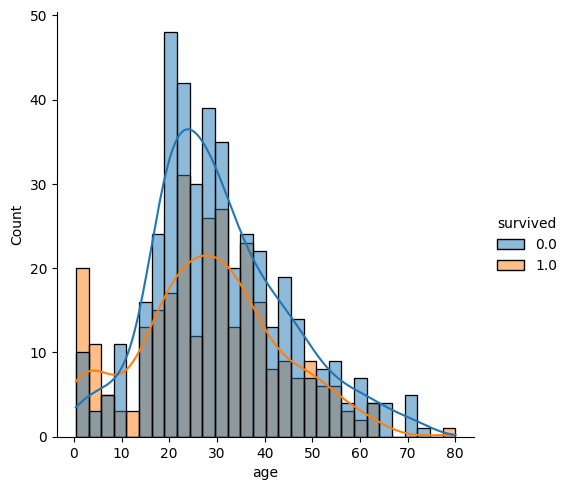

In [8]:
sns.displot(df, x='age', hue='survived', kde=True, bins=30)

проверяем статистику смертности по кабинам, связана ли выжиываемость с какими-то определенными кабинами лучше, чем с другими

<Axes: xlabel='deck', ylabel='count'>

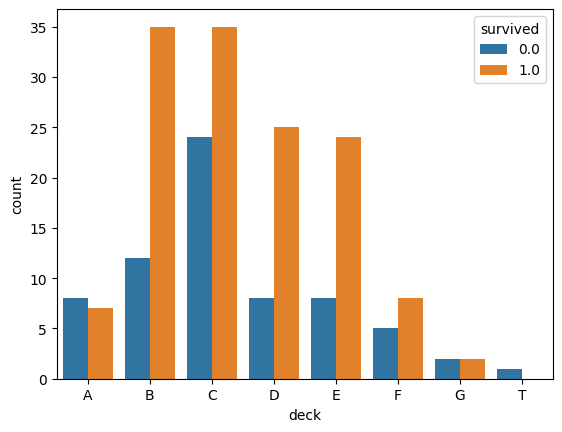

In [9]:
df['deck'] = df['cabin'].str[0]
sns.countplot(df[df['deck'].notnull()], x='deck', hue='survived', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])

и соответственно по классам

<Axes: xlabel='pclass', ylabel='count'>

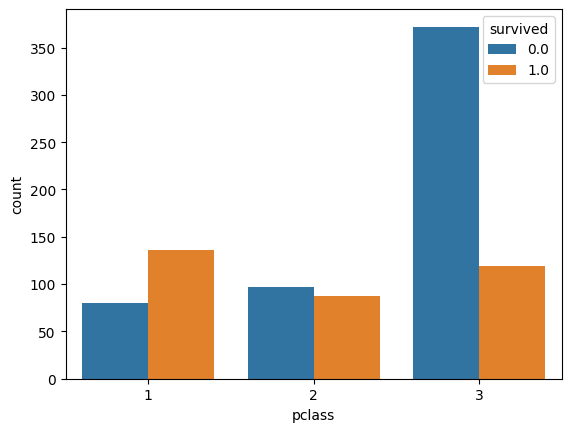

In [10]:
sns.countplot(data=df[df['pclass'].notnull()], x='pclass', hue='survived')

уже видно что есть какое-то влияние кабины и класса на выжиываемость. теперь стоит определить какие кабины к каким классам относятся

<Axes: xlabel='deck', ylabel='count'>

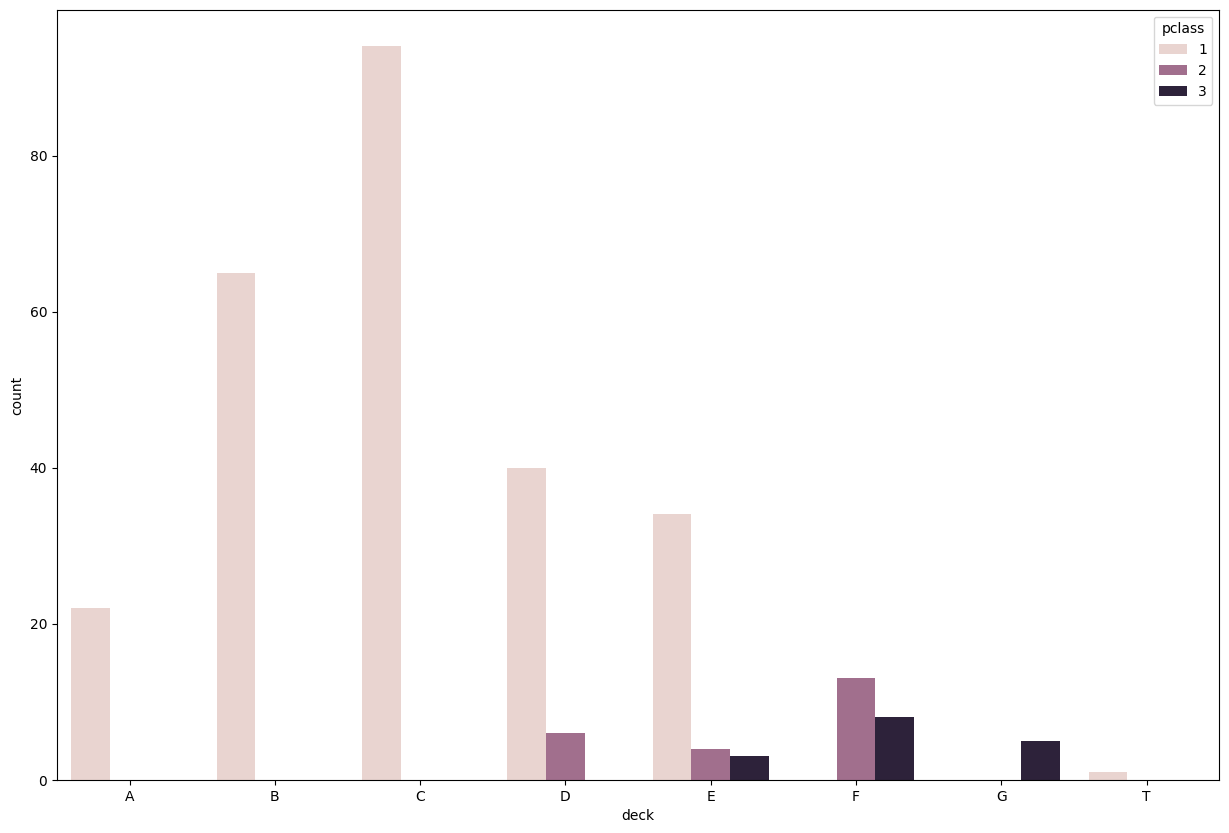

In [11]:
plt.figure(figsize=(15, 10))
sns.countplot(data=df[df['deck'].notnull()], x='deck', hue='pclass', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])

связаны ли как-то кол-во человек в семье с кабиной? (можно сказать что нет)

<Figure size 1500x1000 with 0 Axes>

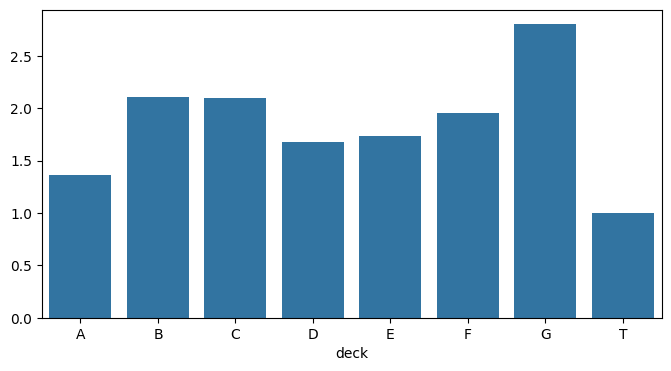

In [12]:
plt.figure(figsize=(15, 10))
df['family_size'] = df['sibsp'] + df['parch'] + 1

deck_mean = df[df['deck'].notnull()].groupby('deck')['family_size'].mean()

plt.figure(figsize=(8, 4))
sns.barplot(x=deck_mean.index, y=deck_mean.values)
plt.show()

In [13]:
df.groupby('deck').describe()

age                                                          fare  \
     count       mean        std    min     25%   50%    75%   max count   
deck                                                                       
A     19.0  44.157895  16.473086   4.00  36.000  41.0  53.50  80.0  22.0   
B     63.0  36.476190  15.706848  11.00  24.000  35.0  48.00  70.0  65.0   
C     86.0  38.382791  14.503884   0.92  28.250  37.0  49.75  76.0  94.0   
D     42.0  39.702381  14.377769  16.00  27.375  42.0  50.50  64.0  46.0   
E     38.0  38.118421  13.546434   6.00  30.250  39.0  47.00  65.0  41.0   
F     18.0  21.333333  12.568635   1.00  13.625  24.5  28.25  42.0  21.0   
G      5.0  12.000000  13.397761   1.00   2.000   4.0  24.00  29.0   5.0   
T      1.0  45.000000        NaN  45.00  45.000  45.0  45.00  45.0   1.0   

                  ... survived      family_size                                \
            mean  ...      75%  max       count      mean       std  min  25%   
deck              ...                                                           
A      41.244314  ...      1.0  1.0        22.0  1.363636  0.726731  1.0  1.0   
B     122.383078  ...      1.0  1.0        65.0  2.107692  1.251538  1.0  1.0   
C     107.926598  ...      1.0  1.0        94.0  2.095745  1.295726  1.0  1.0   
D      53.007339  ...      1.0  1.0        46.0  1.673913  0.634362  1.0  1.0   
E      54.564634  ...      1.0  1.0        41.0  1.731707  0.806982  1.0  1.0   
F      18.079367  ...      1.0  1.0        21.0  1.952381  1.283596  1.0  1.0   
G      14.205000  ...      1.0  1.0         5.0  2.800000  0.447214  2.0  3.0   
T      35.500000  ...      0.0  0.0         1.0  1.000000       NaN  1.0  1.0   

                     
      50%  75%  max  
deck                 
A     1.0  1.0  3.0  
B     2.0  3.0  5.0  
C     2.0  2.0  6.0  
D     2.0  2.0  3.0  
E     2.0  2.0  3.0  
F     1.0  3.0  4.0  
G     3.0  3.0  3.0  
T     1.0  1.0  1.0  

[8 rows x 56 columns]

<Axes: xlabel='deck', ylabel='family_size'>

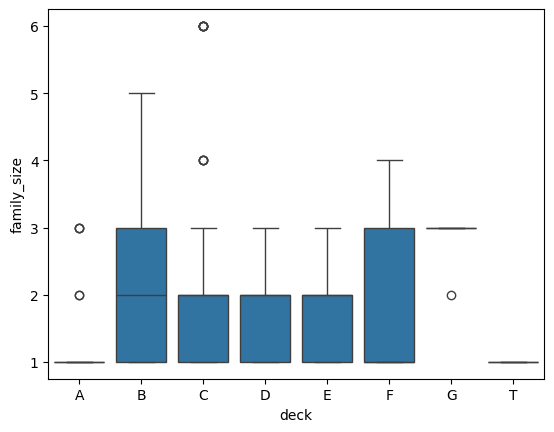

In [14]:
sns.boxplot(data=df[df['deck'].notnull()], x='deck', y='family_size', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])

<Axes: xlabel='deck', ylabel='count'>

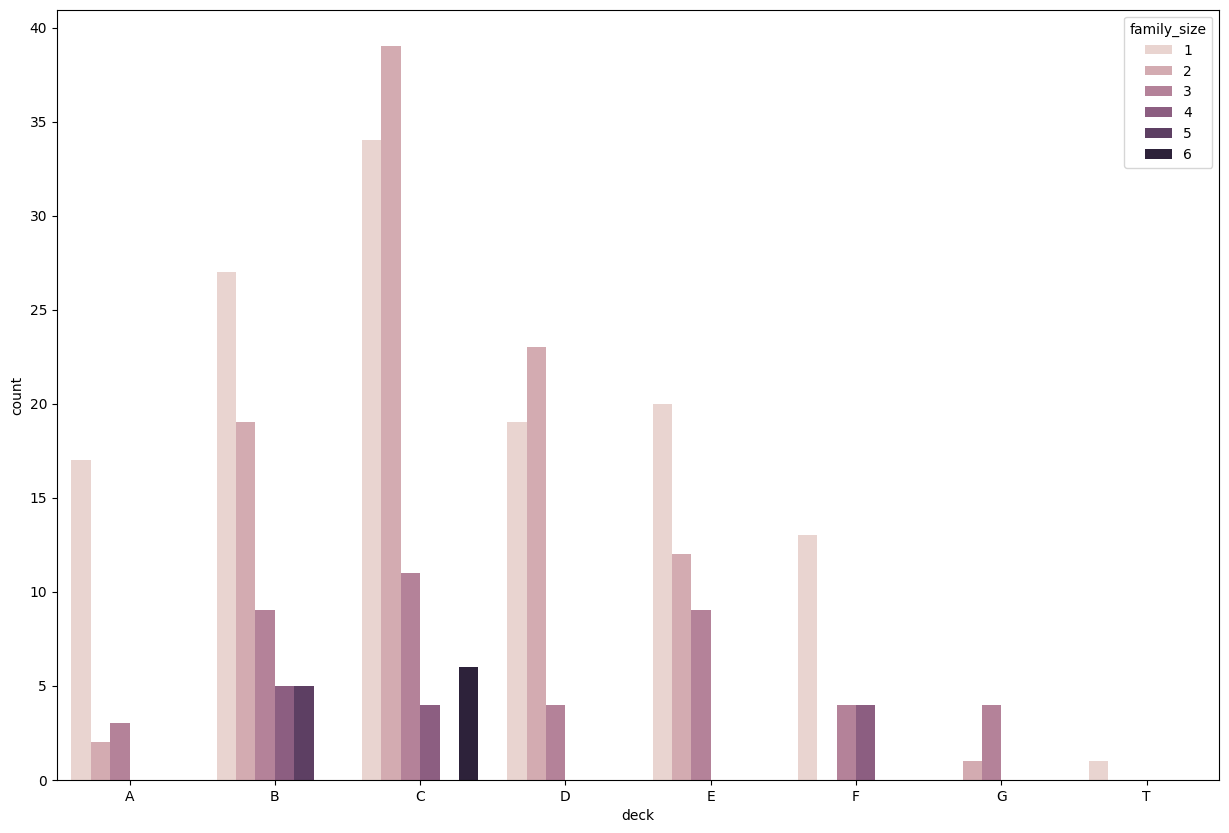

In [15]:
plt.figure(figsize=(15, 10))
sns.countplot(data=df[df['deck'].notnull()], x='deck', hue='family_size', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'])

можно сказать что богатые люди (первый класс) в основном путешествовали малыми группами или одни

In [16]:
df

,age,cabin,embarked,fare,name,parch,pclass,sex,sibsp,survived,ticket,deck,family_size
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,3,male,1,0.0,A/5 21171,NaN,2
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,female,1,1.0,PC 17599,C,2
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,female,0,1.0,STON/O2. 3101282,NaN,1
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,female,1,1.0,113803,C,2
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,3,male,0,0.0,373450,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,NaN,NaN,S,8.0500,"Spector, Mr. Woolf",0,3,male,0,NaN,A.5. 3236,NaN,1
1305,39.0,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1,female,0,NaN,PC 17758,C,1
1306,38.5,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,3,male,0,NaN,SOTON/O.Q. 3101262,NaN,1
1307,NaN,NaN,S,8.0500,"Ware, Mr. Frederick",0,3,male,0,NaN,359309,NaN,1


In [17]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

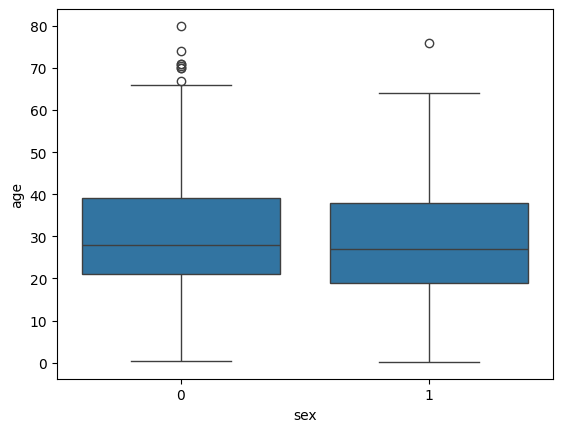

In [18]:
sns.boxplot(data=df[df['age'].notnull()], x='sex', y='age')
plt.show()

по возрасту медиана по полу можно сказать одинаковая, так что соотношение примерно одинаковое

In [19]:
df['initial']=0
for i in df:
    df['initial']=df['name'].str.extract('([A-Za-z]+)\\.')

In [20]:
df['initial'].value_counts()

initial
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

In [21]:
df['initial'] = df['initial'].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['initial'] = df['initial'].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
df['initial'] = df['initial'].astype(int)

In [22]:
df['age'] = df['age'].fillna(df.groupby('initial')['age'].transform('mean')).astype(int)

по званию заполняем пропуски в возрасте, потому что имеется связь между возрастом, семейным положением и званием (что логично)

<Axes: xlabel='age', ylabel='Count'>

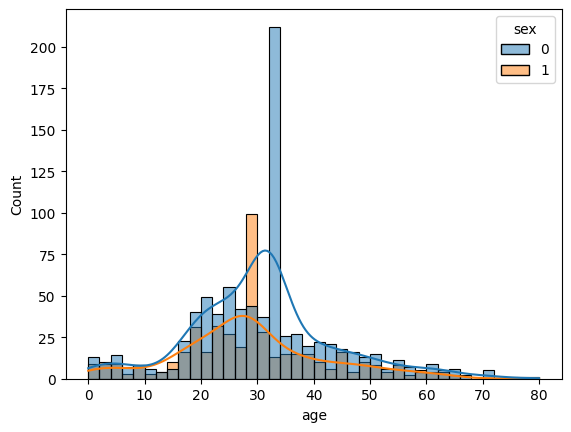

In [23]:
sns.histplot(data=df[df['age'].notnull()], x='age', hue='sex', bins=40, kde=True)

In [24]:
df

,age,cabin,embarked,fare,name,parch,pclass,sex,sibsp,survived,ticket,deck,family_size,initial
0,22,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,3,0,1,0.0,A/5 21171,NaN,2,2
1,38,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,1,1,1,1.0,PC 17599,C,2,1
2,26,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,1,0,1.0,STON/O2. 3101282,NaN,1,1
3,35,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,1,1,1,1.0,113803,C,2,1
4,35,NaN,S,8.0500,"Allen, Mr. William Henry",0,3,0,0,0.0,373450,NaN,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,32,NaN,S,8.0500,"Spector, Mr. Woolf",0,3,0,0,NaN,A.5. 3236,NaN,1,2
1305,39,C105,C,108.9000,"Oliva y Ocana, Dona. Fermina",0,1,1,0,NaN,PC 17758,C,1,3
1306,38,NaN,S,7.2500,"Saether, Mr. Simon Sivertsen",0,3,0,0,NaN,SOTON/O.Q. 3101262,NaN,1,2
1307,32,NaN,S,8.0500,"Ware, Mr. Frederick",0,3,0,0,NaN,359309,NaN,1,2


<Axes: xlabel='embarked', ylabel='count'>

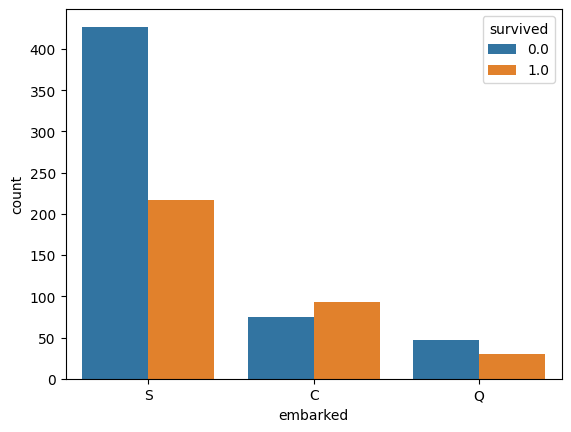

In [25]:
sns.countplot(data=df, x='embarked', hue='survived')

проанализировали откуда больше всего народу село, это поможет дозаполнить пробелы

In [26]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [27]:
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()}')

age: 0
cabin: 1014
embarked: 0
fare: 1
name: 0
parch: 0
pclass: 0
sex: 0
sibsp: 0
survived: 418
ticket: 0
deck: 1014
family_size: 0
initial: 0


<Axes: xlabel='survived', ylabel='count'>

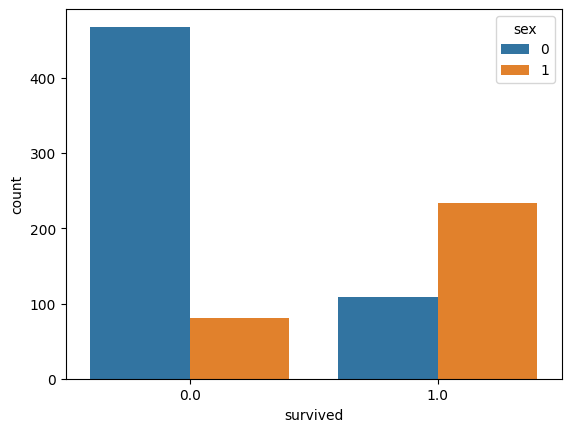

In [28]:
sns.countplot(data=df[df['survived'].notnull()], x='survived', hue='sex')

видим что выживали в основном женщины и мужиков почти не жалели

<Axes: xlabel='pclass', ylabel='survived'>

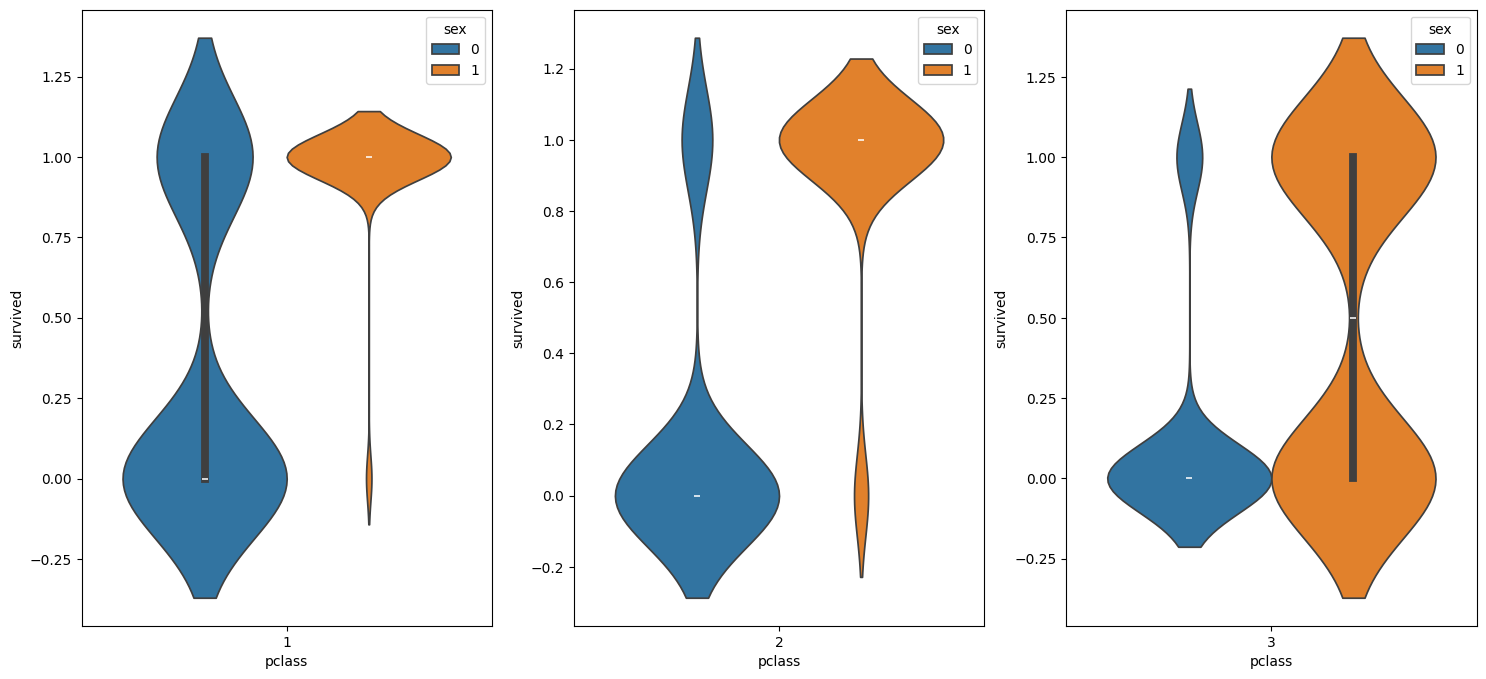

In [29]:
f,ax = plt.subplots(1,3,figsize=(18,8))

sns.violinplot(data=df[(df['survived'].notnull()) & (df['pclass'] == 1)], x='pclass', y='survived', hue='sex', ax=ax[0])
sns.violinplot(data=df[(df['survived'].notnull()) &(df['pclass'] == 2)], x='pclass', y='survived', hue='sex', ax=ax[1])
sns.violinplot(data=df[(df['survived'].notnull()) & (df['pclass'] == 3)], x='pclass', y='survived', hue='sex', ax=ax[2])

проанализировли как связан класс с полом и выживаемостью и видим, что женщины преимущественно выживали, что показал предыдущий график, но и видим что из мужчин выжиывали преимущественно мужчины первого класса

<Axes: xlabel='parch', ylabel='count'>

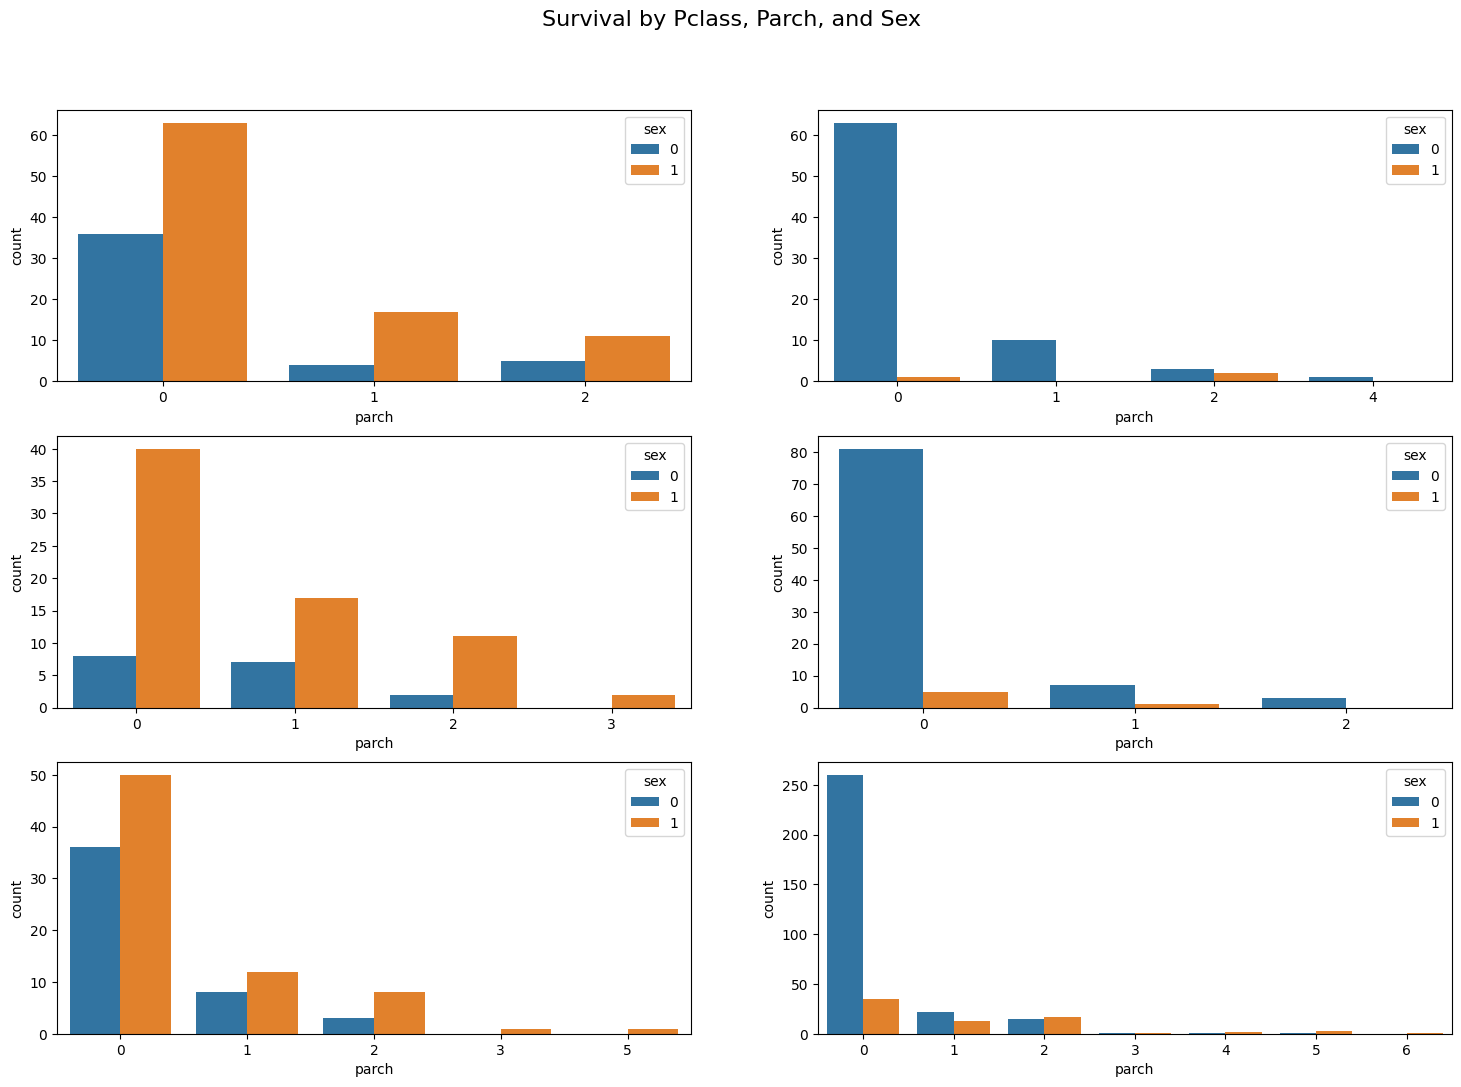

In [30]:
f, ax = plt.subplots(3, 2, figsize=(18, 12))
plt.figtext(0.5, 0.95, 'Survival by Pclass, Parch, and Sex', ha='center', fontsize=16)
sns.countplot(data=df[(df['survived'] == 1) & (df['pclass'] == 1)], x='parch', hue='sex', ax=ax[0, 0])
sns.countplot(data=df[(df['survived'] == 0) & (df['pclass'] == 1)], x='parch', hue='sex', ax=ax[0, 1])
sns.countplot(data=df[(df['survived'] == 1) & (df['pclass'] == 2)], x='parch', hue='sex', ax=ax[1, 0])
sns.countplot(data=df[(df['survived'] == 0) & (df['pclass'] == 2)], x='parch', hue='sex', ax=ax[1, 1])
sns.countplot(data=df[(df['survived'] == 1) & (df['pclass'] == 3)], x='parch', hue='sex', ax=ax[2, 0]) 
sns.countplot(data=df[(df['survived'] == 0) & (df['pclass'] == 3)], x='parch', hue='sex', ax=ax[2, 1])


проанализировал выживаемость по классу, полу и размеру семьи

- видно что в первом классе выживали в основном женщины из небольших семей, одиночки имеют неплохую выживаемость с сравнении с другими группами семей
- в целом видим тенденцию что выживают скорее маленькие группы, а большие наоборот, то есть слишком большой размер семьи чаще приводит к смерти

In [31]:
df['is_mother'] = ((df['parch'] > 0) & (df['initial'] == 'Mrs')).astype(int)

In [33]:
df['deck'] = df['deck'].fillna('U')

In [34]:
idx = df[df['deck'] == 'T'].index
df.loc[idx, 'deck'] = 'A'

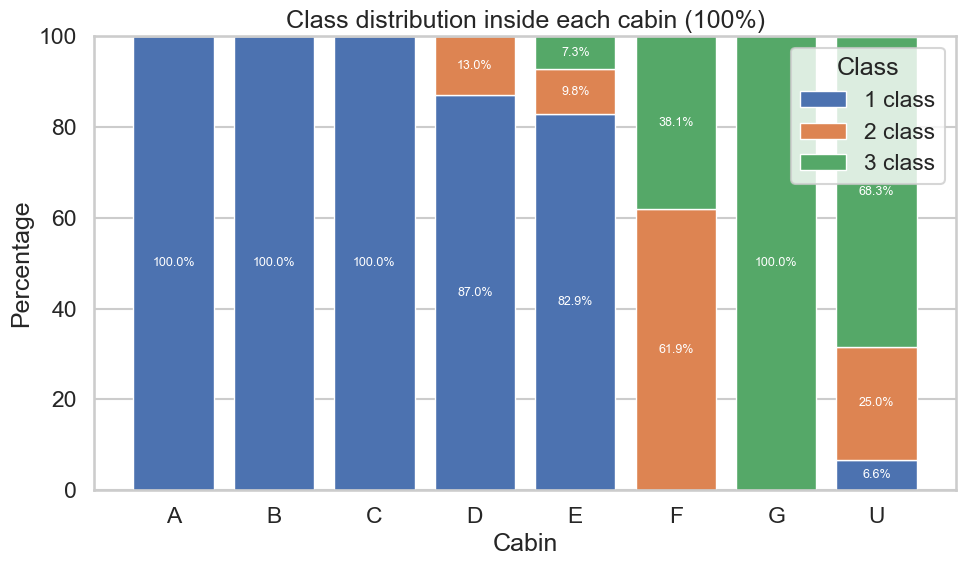

In [35]:
d = df.loc[ (df["deck"].notna()), ["deck", "pclass"]].copy()

cabin_order = sorted(d["deck"].unique())

pct = (
    pd.crosstab(d["deck"], d["pclass"], normalize="index")
    .mul(100)
    .reindex(index=cabin_order, columns=[1, 2, 3], fill_value=0)
    .round(1)
)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

bottom = pd.Series(0.0, index=pct.index)
colors = {1: "#4C72B0", 2: "#DD8452", 3: "#55A868"}

for cls in [1, 2, 3]:
    vals = pct[cls].values
    bars = ax.bar(
        pct.index.astype(str),
        vals,
        bottom=bottom.values,
        color=colors[cls],
        edgecolor="white",
        linewidth=1,
        label=f"{cls} class"
    )
    for i, v in enumerate(vals):
        if v >= 5:
            ax.text(i, bottom.iloc[i] + v / 2, f"{v:.1f}%", ha="center", va="center", color="white", fontsize=9)
    bottom += vals

ax.set_ylim(0, 100)
ax.set_ylabel("Percentage")
ax.set_xlabel("Cabin")
ax.set_title("Class distribution inside each cabin (100%)")
ax.legend(title="Class")
plt.tight_layout()
plt.show()


проанализировал соотношение класса к кабине и видим что первые 3 кабины точно были заняты первым классом

<Axes: xlabel='deck', ylabel='count'>

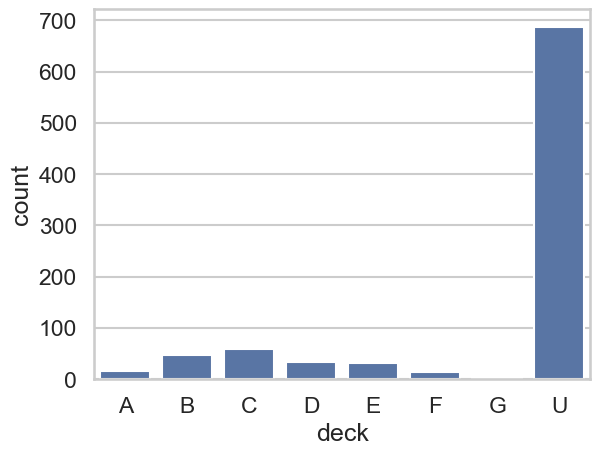

In [36]:
sns.countplot(data=df[df['survived'].notnull()], x='deck', order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'U'])

<Axes: xlabel='pclass', ylabel='count'>

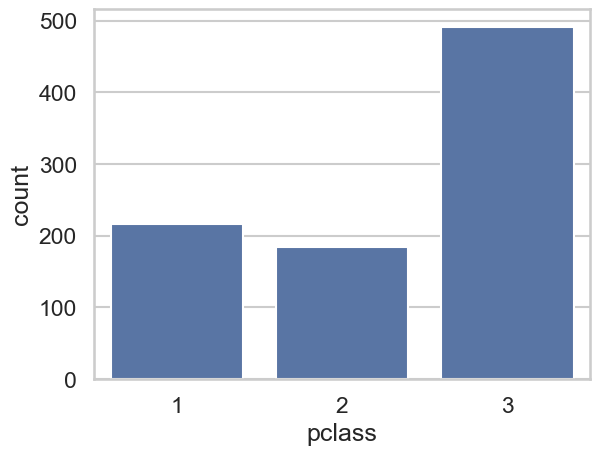

In [37]:
sns.countplot(data=df[df['survived'].notnull()], x='pclass', order=[1, 2, 3])

In [38]:
df['deck'] = df['deck'].replace({
    'A': 'ABC', 'B': 'ABC', 'C': 'ABC',
    'D': 'DE',  'E': 'DE',
    'F': 'FG',  'G': 'FG'
})
df['deck'].value_counts()

deck
U      1014
ABC     182
DE       87
FG       26
Name: count, dtype: int64

<Axes: xlabel='deck', ylabel='count'>

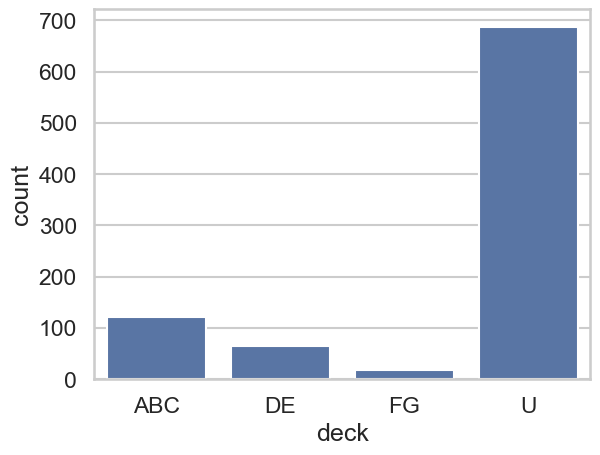

In [39]:
sns.countplot(data=df[df['survived'].notnull()], x='deck', order=['ABC', 'DE', 'FG', 'U'])

постарался сохранить соотношение кол-ва людей к классам при переводе в категориальные значения

In [40]:
df['has_cabin'] = df['deck'].apply(lambda x: 0 if x == 'U' else 1)
df['has_cabin'].value_counts()

has_cabin
0    1014
1     295
Name: count, dtype: int64

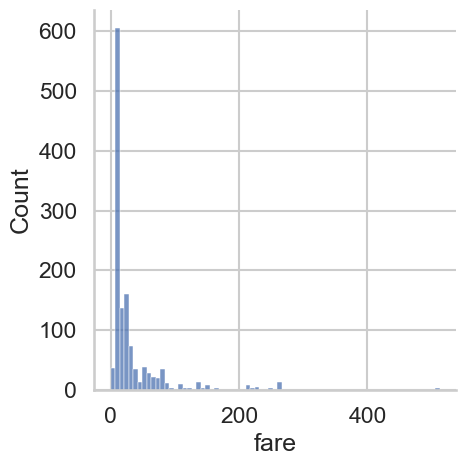

In [41]:
sns.displot(data=df, x='fare')

In [42]:
df['fare'] = df['fare'].fillna(df['fare'].median())
df["fare"]=np.log1p(df["fare"])

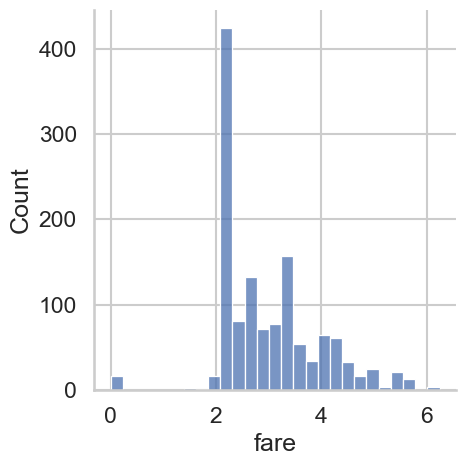

In [43]:
sns.displot(data=df, x='fare')

изучение стоимости тарифа говорит, что было очень много дешевых тарифов, как и кол-во людей 3 класса (тоже преимущество)

In [44]:
df['fare_group'] = pd.qcut(df['fare'], 6, labels=False)

In [45]:
ticket_counts = df.groupby('ticket')['ticket'].transform('count')
df['ticket_group_size'] = ticket_counts

In [46]:
df.drop(columns=['name', 'cabin', 'ticket'], inplace=True)
df


,age,embarked,fare,parch,pclass,sex,sibsp,survived,deck,family_size,initial,is_mother,has_cabin,fare_group,ticket_group_size
0,22,S,2.110213,0,3,0,1,0.0,U,2,2,0,0,0,1
1,38,C,4.280593,0,1,1,1,1.0,ABC,2,1,0,1,5,2
2,26,S,2.188856,0,3,1,0,1.0,U,1,1,0,0,1,1
3,35,S,3.990834,0,1,1,1,1.0,ABC,2,1,0,1,4,2
4,35,S,2.202765,0,3,0,0,0.0,U,1,2,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,32,S,2.202765,0,3,0,0,NaN,U,1,2,0,0,1,1
1305,39,C,4.699571,0,1,1,0,NaN,ABC,1,3,0,1,5,3
1306,38,S,2.110213,0,3,0,0,NaN,U,1,2,0,0,0,1
1307,32,S,2.202765,0,3,0,0,NaN,U,1,2,0,0,1,1


In [47]:
df['is_mother_with_children'] = df['is_mother'] * (df['parch'])

зная что женщины выживали чаще (и дети тоже, потому что женщин с детьми спасали в первую очередь), добавил фичу на данный случай

In [48]:
df['family_size'].value_counts().sort_index()

family_size
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64

In [49]:
df.loc[df['age'] < 7, 'age_group'] = 0
df.loc[(df['age'] >= 7) & (df['age'] < 22), 'age_group'] = 1
df.loc[(df['age'] >= 22) & (df['age'] < 39), 'age_group'] = 2
df.loc[(df['age'] >= 39) & (df['age'] < 50), 'age_group'] = 3
df.loc[(df['age'] >= 50), 'age_group']=4

In [50]:
df.loc[df['family_size'] == 1, 'family_size_group'] = 0
df.loc[(df['family_size'] >= 2) & (df['family_size'] < 5), 'family_size_group'] = 1
df.loc[(df['family_size'] >= 5) & (df['family_size'] < 7), 'family_size_group'] = 2
df.loc[(df['family_size'] >= 7) & (df['family_size'] < 12), 'family_size_group'] = 3
df.loc[(df['family_size'] >= 12), 'family_size_group']=4

сгруппировал семьи по кол-ву человек

In [51]:
to_label_encode = ['deck', 'embarked']
for col in to_label_encode:
    df[col] = LabelEncoder().fit_transform(df[col])

In [52]:
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()}')

age: 0
embarked: 0
fare: 0
parch: 0
pclass: 0
sex: 0
sibsp: 0
survived: 418
deck: 0
family_size: 0
initial: 0
is_mother: 0
has_cabin: 0
fare_group: 0
ticket_group_size: 0
is_mother_with_children: 0
age_group: 0
family_size_group: 0


In [53]:
df

,age,embarked,fare,parch,pclass,sex,sibsp,survived,deck,family_size,initial,is_mother,has_cabin,fare_group,ticket_group_size,is_mother_with_children,age_group,family_size_group
0,22,2,2.110213,0,3,0,1,0.0,3,2,2,0,0,0,1,0,2.0,1.0
1,38,0,4.280593,0,1,1,1,1.0,0,2,1,0,1,5,2,0,2.0,1.0
2,26,2,2.188856,0,3,1,0,1.0,3,1,1,0,0,1,1,0,2.0,0.0
3,35,2,3.990834,0,1,1,1,1.0,0,2,1,0,1,4,2,0,2.0,1.0
4,35,2,2.202765,0,3,0,0,0.0,3,1,2,0,0,1,1,0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,32,2,2.202765,0,3,0,0,NaN,3,1,2,0,0,1,1,0,2.0,0.0
1305,39,0,4.699571,0,1,1,0,NaN,0,1,3,0,1,5,3,0,3.0,0.0
1306,38,2,2.110213,0,3,0,0,NaN,3,1,2,0,0,0,1,0,2.0,0.0
1307,32,2,2.202765,0,3,0,0,NaN,3,1,2,0,0,1,1,0,2.0,0.0


In [54]:
train_df = df[df['survived'].notnull()].copy()
test_df = df[df['survived'].isnull()].drop(columns=['survived']).copy()

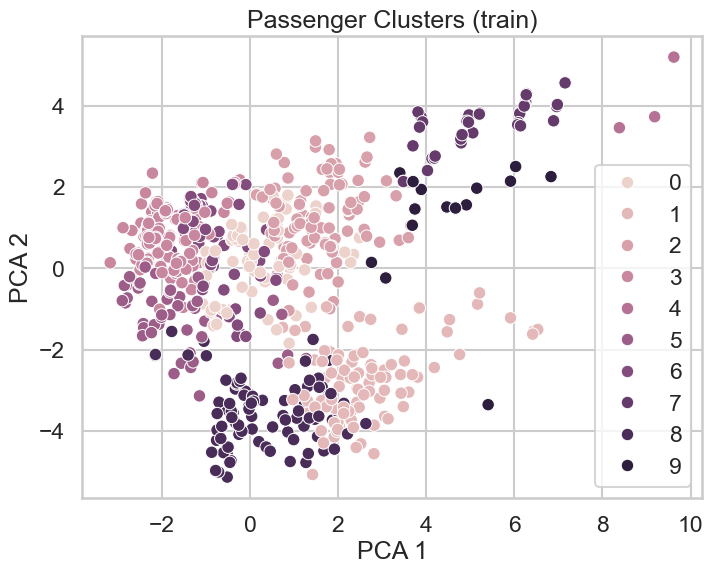

In [55]:
features = df.columns.difference(['survived'])
X_train = train_df[features].select_dtypes(include=[np.number]).copy()
X_test  = test_df[features].select_dtypes(include=[np.number]).copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

kmeans = KMeans(n_clusters=10, random_state=42, n_init="auto")
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters  = kmeans.predict(X_test_scaled)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=train_clusters,
    legend="full"
)
plt.title("Passenger Clusters (train)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

train_df["cluster"] = train_clusters
test_df["cluster"]  = test_clusters

In [56]:
train_df.groupby("cluster").mean()

,age,embarked,fare,parch,pclass,sex,sibsp,survived,deck,family_size,initial,is_mother,has_cabin,fare_group,ticket_group_size,is_mother_with_children,age_group,family_size_group
cluster,,,,,,,,,,,,,,,,,,
0,30.226190,1.547619,3.368581,0.309524,2.285714,0.000000,0.738095,0.142857,2.988095,2.047619,2.011905,0.0,0.011905,3.535714,3.047619,0.0,1.976190,0.678571
1,30.881720,1.043011,4.659073,0.655914,1.000000,0.860215,0.580645,0.924731,0.505376,2.236559,1.075269,0.0,0.924731,4.881720,3.225806,0.0,2.096774,0.774194
2,18.855856,1.468468,3.076245,0.927928,2.513514,0.828829,0.801802,0.801802,2.882883,2.729730,0.828829,0.0,0.099099,3.045045,2.612613,0.0,1.279279,0.990991
3,28.287582,1.663399,2.165224,0.013072,2.836601,0.000000,0.058824,0.107843,2.980392,1.071895,2.009804,0.0,0.016340,0.892157,1.104575,0.0,1.852941,0.052288
4,26.428571,2.000000,4.256322,2.000000,3.000000,0.428571,8.000000,0.000000,3.000000,11.000000,1.285714,0.0,0.000000,5.000000,11.000000,0.0,1.714286,3.000000
5,53.400000,1.740000,2.838453,0.060000,2.060000,0.120000,0.100000,0.200000,3.000000,1.160000,2.060000,0.0,0.000000,2.320000,1.260000,0.0,3.720000,0.120000
6,27.216495,1.494845,2.404042,0.010309,2.659794,1.000000,0.082474,0.680412,2.865979,1.092784,1.000000,0.0,0.082474,1.257732,1.144330,0.0,1.876289,0.092784
7,9.305556,1.888889,3.457347,1.555556,3.000000,0.444444,3.722222,0.083333,3.000000,6.277778,0.611111,0.0,0.000000,3.722222,6.250000,0.0,0.666667,2.388889
8,42.945652,1.380435,3.645907,0.119565,1.032609,0.097826,0.293478,0.423913,0.336957,1.413043,2.043478,0.0,1.000000,4.021739,1.576087,0.0,2.815217,0.336957


разбил на кластеры чтобы посмотреть какие есть закономерности и желая подсмотреть что-то интересное дополнительно

- выжиывают в основном женщины из первого класса с дорогим тарифом и семьей из двух человек. ребенок имелся чуть больше чем в половине случаев
- далее высокую выживаемость имеют женщины из 2-3 класса у которых чаще всего был ребенок. частично даже похоже на группу которую описал выше
- далее можно увидеть женщин 27 лет тоже из 2-3 класса
- из интересного у детей (средний возраст 9 лет) выживаемость - 0.08, кринж
- хотелось бы сказать что мужики откидываются почти всегда, но топ-4 по выживаемости именно богатые мужики из первого класса в среднем 43 лет (старики могли бы и детям отдать места)
- в топ-4 выживают преимущественно небольшие семьи 

<Axes: >

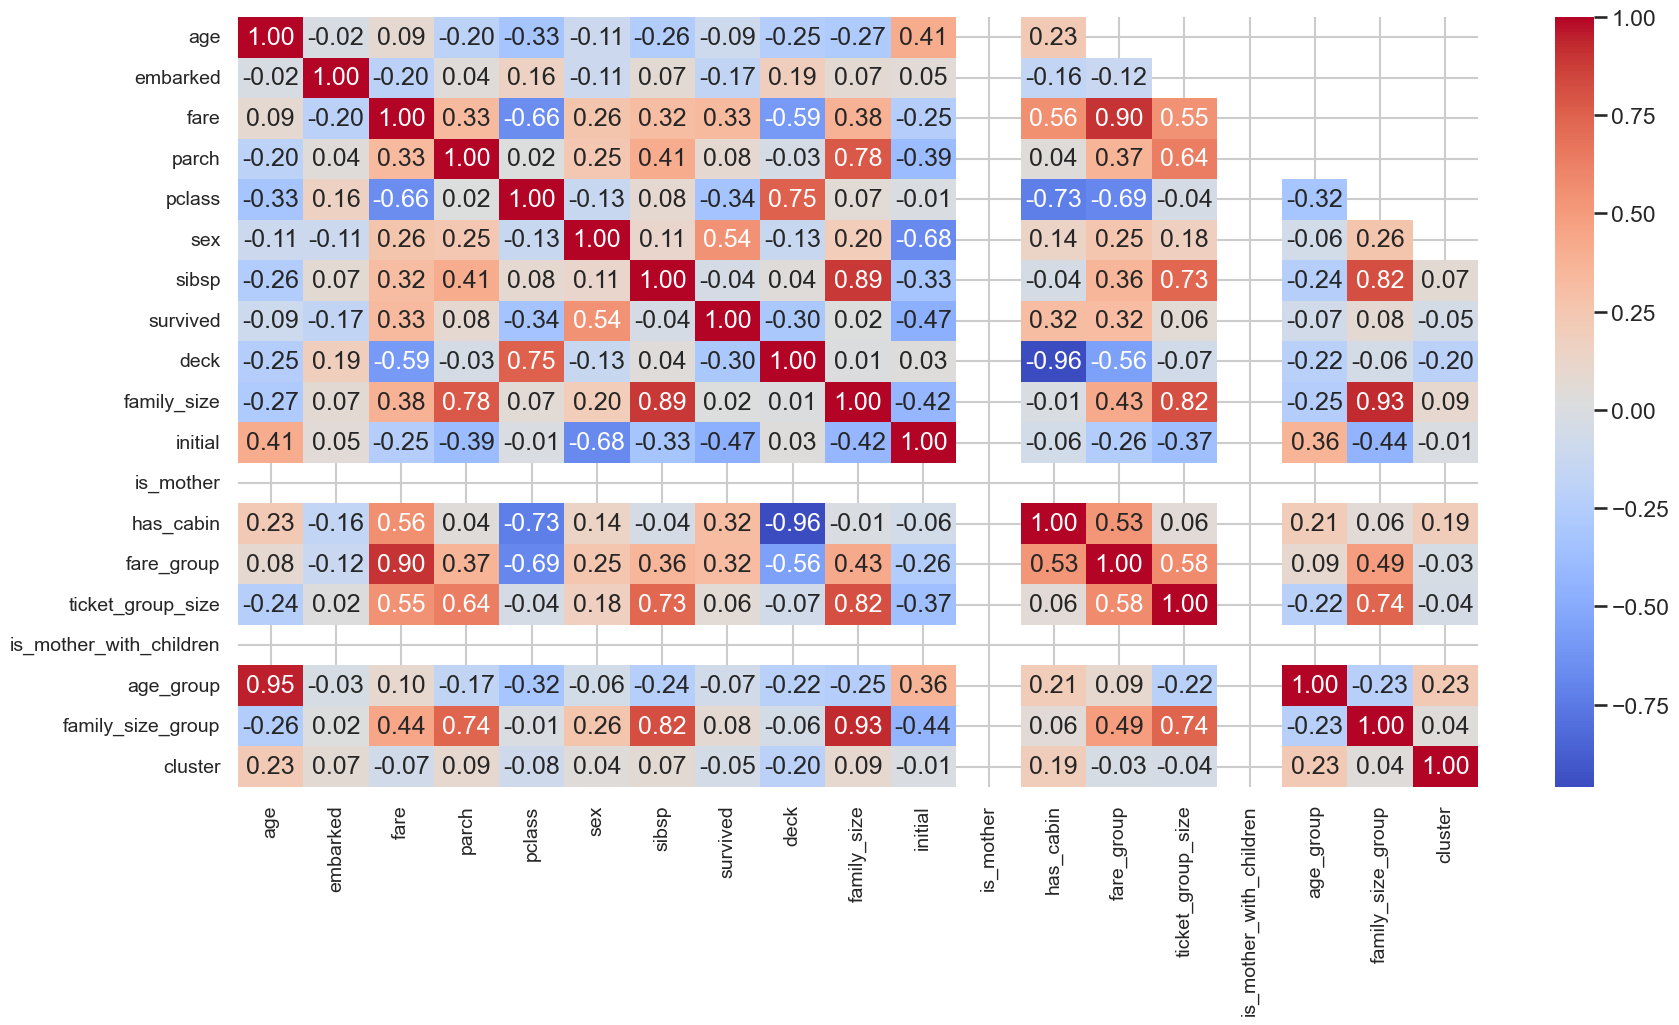

In [57]:
mask = np.triu(np.ones_like(train_df.corr(), dtype=bool), 13)
fig=plt.gcf()
fig.set_size_inches(20,10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", mask=mask)

определив корреляции можно сделать выводы, что нам можно оставить и что дает нам больше профита

In [58]:
train_df.drop(columns=['sibsp', 'parch', 'family_size', 'fare_group', 'is_mother_with_children', 'is_mother', 'age_group'], inplace=True)
test_df.drop(columns=['sibsp', 'parch', 'family_size', 'fare_group', 'is_mother_with_children', 'is_mother', 'age_group'], inplace=True)

In [59]:
y = train_df['survived']
X = train_df.drop(columns=['survived'])

test_df = test_df[X.columns]

In [60]:
train_df

,age,embarked,fare,pclass,sex,survived,deck,initial,has_cabin,ticket_group_size,family_size_group,cluster
0,22,2,2.110213,3,0,0.0,3,2,0,1,1.0,3
1,38,0,4.280593,1,1,1.0,0,1,1,2,1.0,1
2,26,2,2.188856,3,1,1.0,3,1,0,1,0.0,6
3,35,2,3.990834,1,1,1.0,0,1,1,2,1.0,1
4,35,2,2.202765,3,0,0.0,3,2,0,1,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27,2,2.639057,2,0,0.0,3,3,0,1,0.0,3
887,19,2,3.433987,1,1,1.0,0,1,1,1,0.0,1
888,28,2,3.196630,3,1,0.0,3,1,0,4,1.0,2
889,26,0,3.433987,1,0,1.0,0,2,1,1,0.0,8


# Shap check

In [385]:
params = study_xgb.best_params

In [414]:
params['n_estimators'] = 1500

In [416]:
model = XGBClassifier(
        **params,
        random_seed=42,
        verbose=-1,
    )
model.fit(X_train, y_train)
# preds = model.predict(test_df)
preds = model.predict(X_val)
print(classification_report(y_val, preds))

# threshold = 0.47
# pred = (proba >= threshold).astype(int)

# print(classification_report(y_test, preds.astype(int)))

# submission = pd.DataFrame({
#         "PassengerId": df_test["PassengerId"],
#         "Survived": preds.astype(int)
#     })

# submission.to_csv("catboost.csv", index=False)

d:\progs\titanic\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:12:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "random_seed", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.85      0.89      0.87       110
         1.0       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



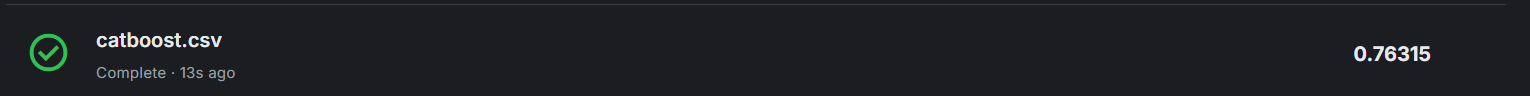

In [423]:
params = study_rf.best_params
params['n_estimators'] = 5000

In [424]:
model = RandomForestClassifier(
        **params
    )
model.fit(X_train, y_train)
preds = model.predict(X_val)
# threshold = 0.47
# pred = (proba >= threshold).astype(int)

print(classification_report(y_val, preds.astype(int)))

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88       110
         1.0       0.86      0.72      0.79        69

    accuracy                           0.85       179
   macro avg       0.85      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



In [212]:
preds = model.predict(test_df)
submission = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": preds.astype(int)
    })

submission.to_csv("RandomForestClassifier2.csv", index=False)

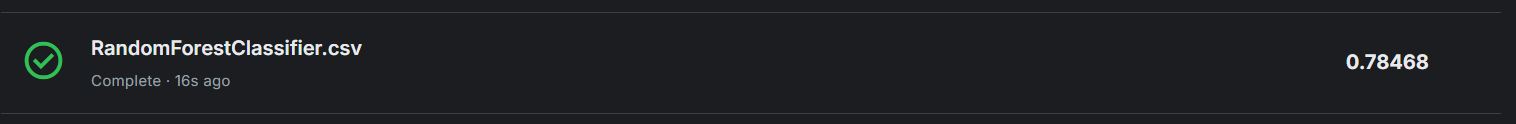
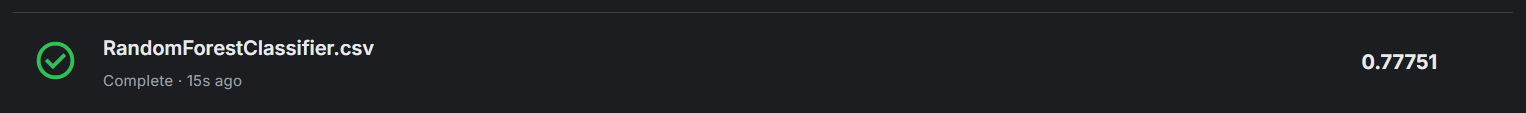

 94%|=================== | 338/358 [00:16<00:00]       

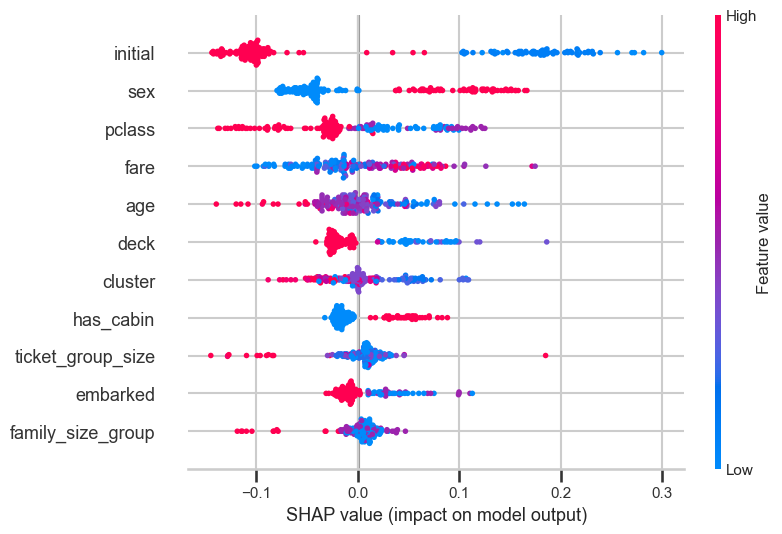

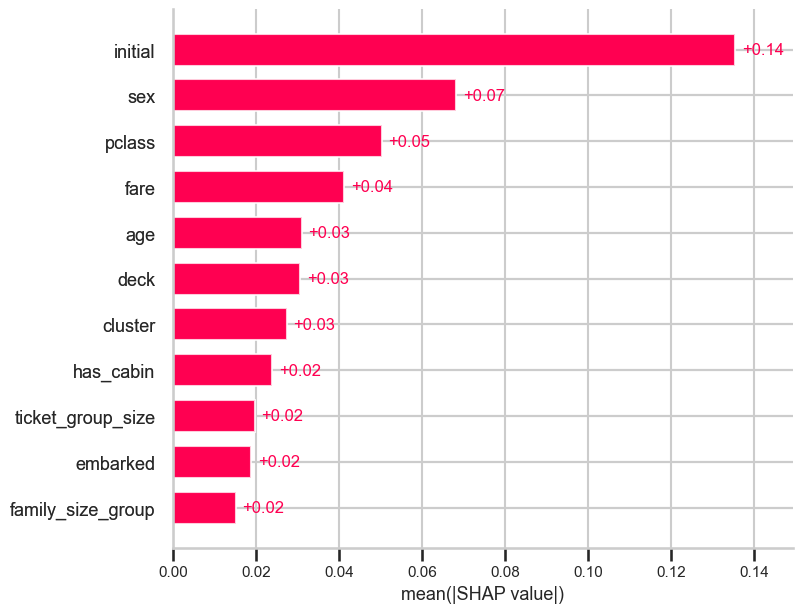

In [115]:
X_shap = X_val.copy()

explainer = shap.Explainer(model, X_shap)
shap_values = explainer(X_shap)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=25)
shap.plots.bar(shap_values[:, :, 1], max_display=25)